<a href="https://colab.research.google.com/github/janathiru25/Animal-Image-Classification/blob/main/Animal_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
!pip install -q kaggle

In [3]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jaanuuhh","key":"046ec0ada3e535669b7759fa25edcdbc"}'}

In [4]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle API configured successfully!")

Kaggle API configured successfully!


In [5]:
!kaggle datasets download -d alessiocorrado99/animals10

Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
100% 586M/586M [00:05<00:00, 104MB/s]



In [31]:
import zipfile

zip_path = "animals10.zip"

extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [32]:
import os

print(os.listdir("dataset"))

['Animal Classification', 'raw-img', 'translate.py']


In [33]:
dataset_path = "dataset/raw-img"

classes = sorted(os.listdir(dataset_path))

print("Number of Classes:", len(classes))
print(classes)

Number of Classes: 10
['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


In [34]:
import os

folder = "dataset/raw-img"

rename_dict = {
    "cane": "Dog",
    "gatto": "Cat",
    "cavallo": "Horse",
    "mucca": "Cow",
    "gallina": "Chicken",
    "pecora": "Sheep",
    "elefante": "Elephant",
    "farfalla": "Butterfly",
    "ragno": "Spider",
    "scoiattolo": "Squirrel"
}

for old_name, new_name in rename_dict.items():
    old_path = os.path.join(folder, old_name)
    new_path = os.path.join(folder, new_name)

    if os.path.exists(old_path):
        os.rename(old_path, new_path)

print("✅ Folder names converted to English!")

✅ Folder names converted to English!


In [36]:
import os

dataset_path = "dataset/raw-img"

classes = sorted(os.listdir(dataset_path))

print(classes)

['Butterfly', 'Cat', 'Chicken', 'Cow', 'Dog', 'Elephant', 'Horse', 'Sheep', 'Spider', 'Squirrel']


In [37]:
# ==============================
# Import Required Libraries
# ==============================

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from torch.utils.data import DataLoader, random_split

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [39]:
dataset_path = "dataset/raw-img"

print("Dataset Path:", dataset_path)

Dataset Path: dataset/raw-img


In [40]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

valid_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

print("✅ Image transformations created.")

✅ Image transformations created.


In [41]:
full_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform
)

print("Total Images :", len(full_dataset))

print("Classes :", full_dataset.classes)

Total Images : 26179
Classes : ['Butterfly', 'Cat', 'Chicken', 'Cow', 'Dog', 'Elephant', 'Horse', 'Sheep', 'Spider', 'Squirrel']


In [42]:
train_size = int(0.8 * len(full_dataset))

valid_size = len(full_dataset) - train_size

train_dataset, valid_dataset = random_split(
    full_dataset,
    [train_size, valid_size]
)

print("Training Images :", len(train_dataset))
print("Validation Images :", len(valid_dataset))

Training Images : 20943
Validation Images : 5236


In [43]:
valid_dataset.dataset.transform = valid_transform

print("✅ Validation Transform Applied")

✅ Validation Transform Applied


In [44]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("✅ DataLoaders Created")

✅ DataLoaders Created


In [45]:
images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Batch Shape : torch.Size([32])


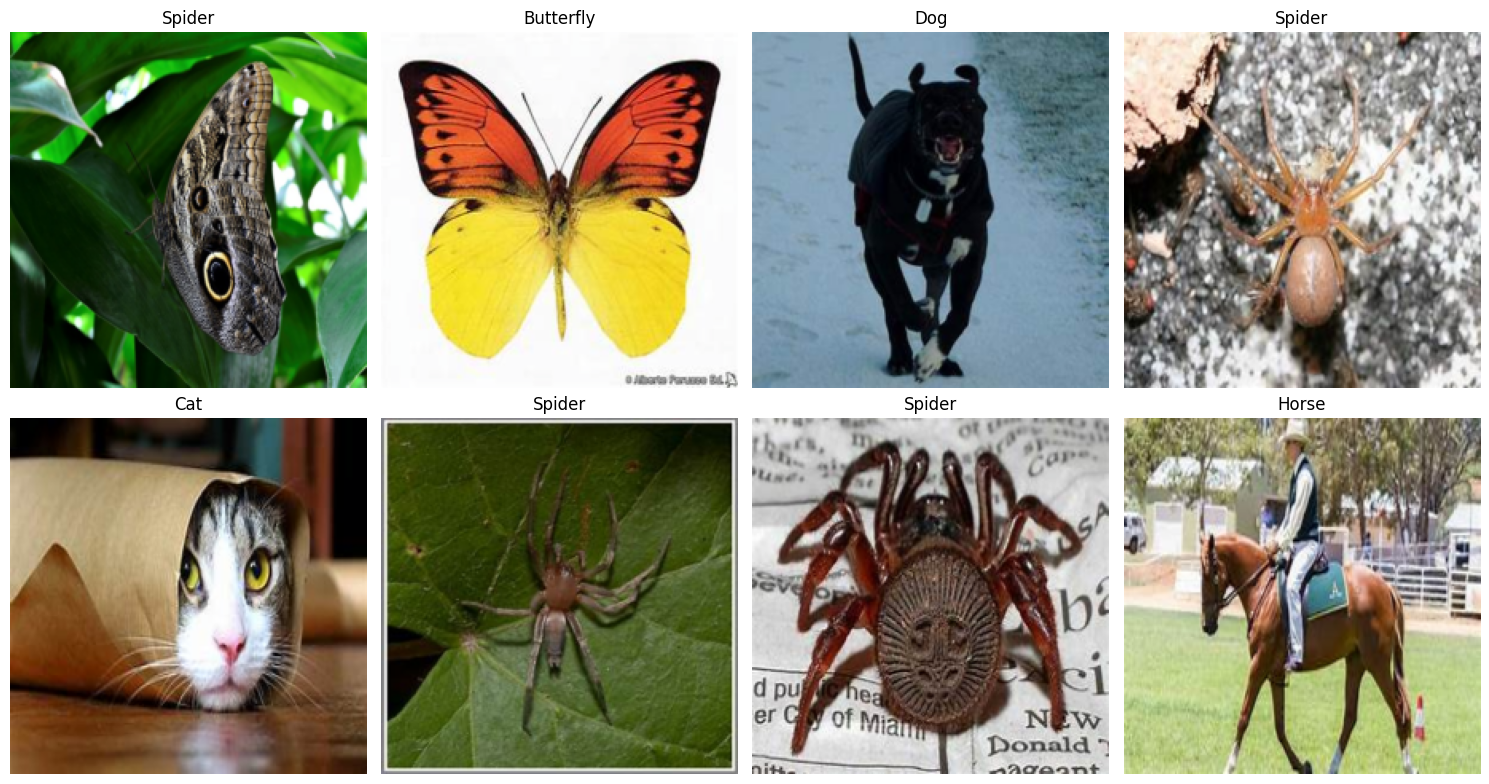

In [46]:
classes = full_dataset.classes

plt.figure(figsize=(15,8))

for i in range(8):

    image = images[i].permute(1,2,0).numpy()

    image = image * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])

    image = np.clip(image,0,1)

    plt.subplot(2,4,i+1)
    plt.imshow(image)
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [47]:
# ============================================
# Load Pretrained EfficientNet-B0
# ============================================

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

print("✅ EfficientNet-B0 Loaded Successfully!")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 75.0MB/s]


✅ EfficientNet-B0 Loaded Successfully!


In [48]:
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [49]:
# ============================================
# Freeze Feature Extraction Layers
# ============================================

for param in model.features.parameters():
    param.requires_grad = False

print("✅ Feature extractor frozen!")

✅ Feature extractor frozen!


In [50]:
# ============================================
# Replace Final Classification Layer
# ============================================

num_classes = len(full_dataset.classes)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(
        in_features=1280,
        out_features=num_classes
    )
)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=10, bias=True)
)


In [51]:
model = model.to(device)

print("✅ Model moved to:", device)

✅ Model moved to: cuda


In [52]:
# ============================================
# Loss Function
# ============================================

criterion = nn.CrossEntropyLoss()

print("Loss Function:", criterion)

Loss Function: CrossEntropyLoss()


In [53]:
# ============================================
# Optimizer
# ============================================

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [54]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable Parameters: {trainable:,}")
print(f"Total Parameters: {total:,}")

Trainable Parameters: 12,810
Total Parameters: 4,020,358


In [55]:
# ============================================
# Test Forward Pass
# ============================================

images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Output Shape:", outputs.shape)

Output Shape: torch.Size([32, 10])


In [56]:
# ============================================
# Test Forward Pass
# ============================================

images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Output Shape:", outputs.shape)

Output Shape: torch.Size([32, 10])


In [58]:
# ==========================================
# Initialize Training Variables
# ==========================================

num_epochs = 10

train_losses = []
valid_losses = []

train_accuracies = []
valid_accuracies = []

best_accuracy = 0

print("✅ Training Variables Initialized")

✅ Training Variables Initialized


In [59]:
# ==========================================
# Training Loop
# ==========================================

for epoch in range(num_epochs):

    # -----------------------
    # Training
    # -----------------------
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # -----------------------
    # Validation
    # -----------------------
    model.eval()

    running_val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    valid_loss = running_val_loss / len(valid_loader)
    valid_accuracy = 100 * correct / total

    valid_losses.append(valid_loss)
    valid_accuracies.append(valid_accuracy)

    # -----------------------
    # Save Best Model
    # -----------------------

    if valid_accuracy > best_accuracy:

        best_accuracy = valid_accuracy

        torch.save(model.state_dict(), "best_model.pth")

    # -----------------------
    # Print Results
    # -----------------------

    print(f"Epoch [{epoch+1}/{num_epochs}]")

    print(f"Train Loss      : {train_loss:.4f}")

    print(f"Train Accuracy  : {train_accuracy:.2f}%")

    print(f"Valid Loss      : {valid_loss:.4f}")

    print(f"Valid Accuracy  : {valid_accuracy:.2f}%")

    print("-"*50)

Epoch [1/10]
Train Loss      : 0.4460
Train Accuracy  : 89.17%
Valid Loss      : 0.1914
Valid Accuracy  : 95.02%
--------------------------------------------------
Epoch [2/10]
Train Loss      : 0.2405
Train Accuracy  : 92.88%
Valid Loss      : 0.1672
Valid Accuracy  : 95.24%
--------------------------------------------------
Epoch [3/10]
Train Loss      : 0.2219
Train Accuracy  : 93.23%
Valid Loss      : 0.1489
Valid Accuracy  : 95.59%
--------------------------------------------------
Epoch [4/10]
Train Loss      : 0.2079
Train Accuracy  : 93.70%
Valid Loss      : 0.1464
Valid Accuracy  : 95.44%
--------------------------------------------------
Epoch [5/10]
Train Loss      : 0.1951
Train Accuracy  : 93.89%
Valid Loss      : 0.1429
Valid Accuracy  : 95.44%
--------------------------------------------------
Epoch [6/10]
Train Loss      : 0.1942
Train Accuracy  : 94.08%
Valid Loss      : 0.1397
Valid Accuracy  : 95.74%
--------------------------------------------------
Epoch [7/10]
Tra

In [60]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [61]:
!pip install seaborn

In [62]:
# Load the best saved model
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

print("✅ Best Model Loaded Successfully!")

✅ Best Model Loaded Successfully!


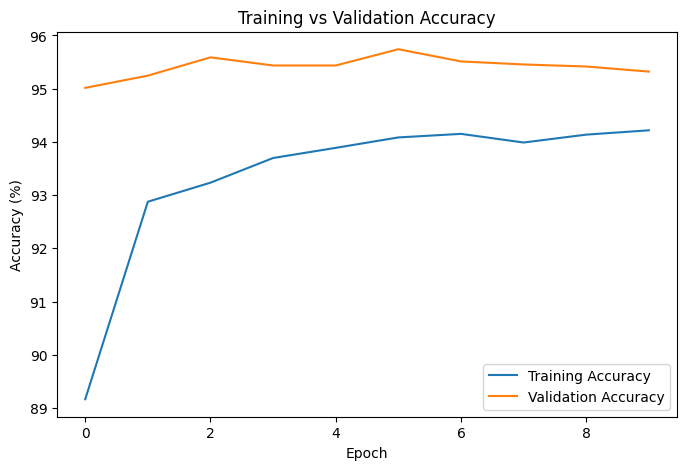

In [63]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(valid_accuracies, label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.show()

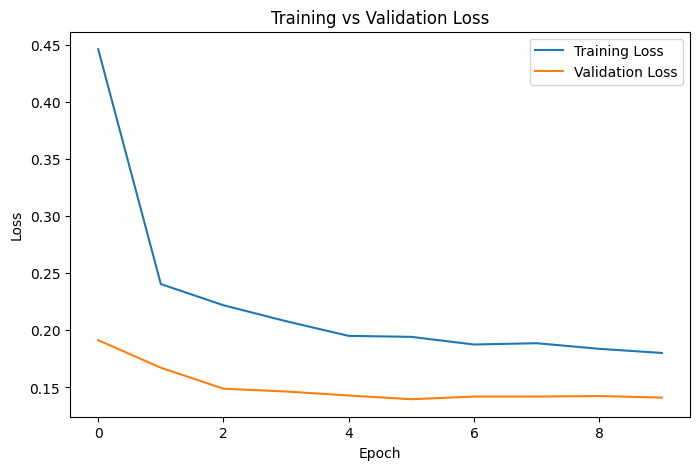

In [64]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(valid_losses, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [65]:
true_labels = []
predicted_labels = []

model.eval()

with torch.no_grad():

    for images, labels in valid_loader:

        images = images.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        true_labels.extend(labels.numpy())

        predicted_labels.extend(predictions.cpu().numpy())

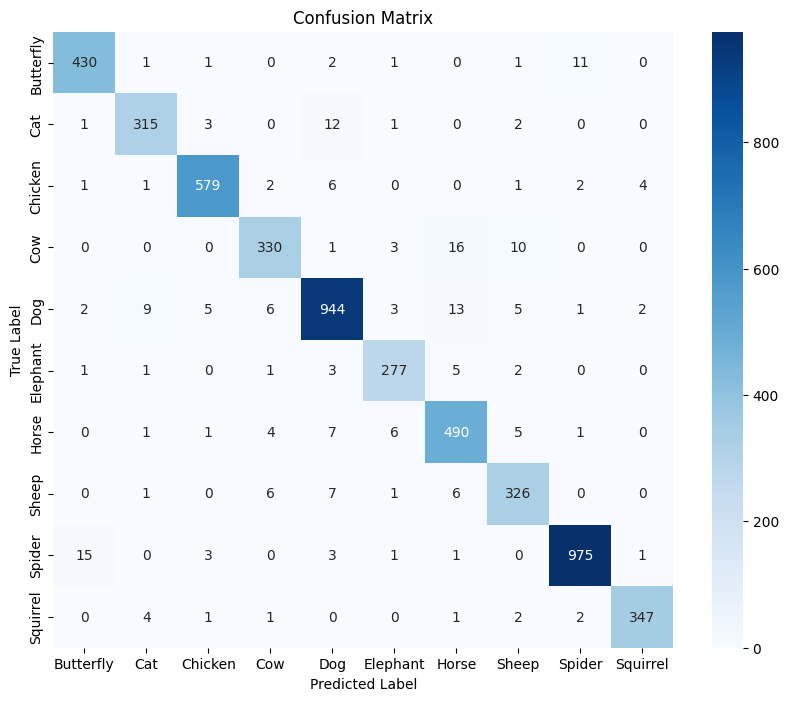

In [66]:
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=full_dataset.classes,
    yticklabels=full_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [67]:
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=full_dataset.classes
))

              precision    recall  f1-score   support

   Butterfly       0.96      0.96      0.96       447
         Cat       0.95      0.94      0.94       334
     Chicken       0.98      0.97      0.97       596
         Cow       0.94      0.92      0.93       360
         Dog       0.96      0.95      0.96       990
    Elephant       0.95      0.96      0.95       290
       Horse       0.92      0.95      0.94       515
       Sheep       0.92      0.94      0.93       347
      Spider       0.98      0.98      0.98       999
    Squirrel       0.98      0.97      0.97       358

    accuracy                           0.96      5236
   macro avg       0.95      0.95      0.95      5236
weighted avg       0.96      0.96      0.96      5236



In [68]:
print("="*50)
print(f"Best Validation Accuracy : {best_accuracy:.2f}%")
print("="*50)

Best Validation Accuracy : 95.74%


In [69]:
from google.colab import files

uploaded = files.upload()

Saving 4.webp to 4.webp


In [70]:
from PIL import Image
import matplotlib.pyplot as plt

In [71]:
weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=None)

model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(1280, 10)
)

model.load_state_dict(torch.load("best_model.pth"))

model.to(device)

model.eval()

print("✅ Best model loaded successfully!")

✅ Best model loaded successfully!


In [72]:
predict_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [73]:
class_names = [
    "Butterfly",
    "Cat",
    "Chicken",
    "Cow",
    "Dog",
    "Elephant",
    "Horse",
    "Sheep",
    "Spider",
    "Squirrel"
]

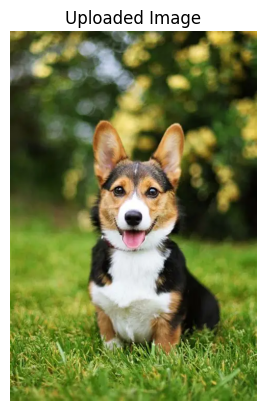

In [74]:
import os

image_name = list(uploaded.keys())[0]

image = Image.open(image_name).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.title("Uploaded Image")
plt.show()

In [75]:
image_tensor = predict_transform(image)

image_tensor = image_tensor.unsqueeze(0)

image_tensor = image_tensor.to(device)

with torch.no_grad():

    outputs = model(image_tensor)

    probabilities = torch.softmax(outputs, dim=1)

    confidence, prediction = torch.max(probabilities,1)

print("="*40)
print("Predicted Animal :", class_names[prediction.item()])
print(f"Confidence : {confidence.item()*100:.2f}%")
print("="*40)

Predicted Animal : Dog
Confidence : 76.17%


In [76]:
top_prob, top_class = torch.topk(probabilities, 3)

print("Top 3 Predictions\n")

for i in range(3):

    print(
        f"{class_names[top_class[0][i]]} : {top_prob[0][i]*100:.2f}%"
    )

Top 3 Predictions

Dog : 76.17%
Cat : 8.54%
Squirrel : 5.41%


In [77]:
torch.save(model.state_dict(), "Animal_EfficientNet_B0.pth")

print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!


In [78]:
from google.colab import files

files.download("Animal_EfficientNet_B0.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>